In [2]:
import os
import time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import cupy as cp
import cudf
from cuml.manifold import TSNE
import matplotlib.pyplot as plt


In [1]:
data = pd.read_csv("../../../../data/resample_standard_all.csv")

# We keep "apogee_id" aside (if needed)
data_id = data["apogee_id"]

PHYS_COLS = ["TEFF", "LOGG", "J", "H", "K"]

# Let's extract the target columns: TEFF, LOGG, J, H, K
# (All assumed to be normalized [0,1] or something similar)
data_target = data[PHYS_COLS].copy()

# We drop them from 'data' to keep only the chemical features (X)
columns_to_drop = ["apogee_id"] + PHYS_COLS
data = data.drop(columns=columns_to_drop)

print("✅ Data Loaded and Preprocessed Successfully!")
print(f"🆔 ID Columns: {data_id.shape}")
print(f"🎯 Target Columns: {data_target.shape}")
print("Columns used as input features:", data.columns)

# Convert to float32
data = data.astype('float32').reset_index(drop=True)
data_target = data_target.astype('float32').reset_index(drop=True)

# Convert to torch tensors
X_full = torch.tensor(data.values, dtype=torch.float32)
y_teff  = torch.tensor(data_target["TEFF"].values, dtype=torch.float32)
y_logg  = torch.tensor(data_target["LOGG"].values, dtype=torch.float32)
y_j     = torch.tensor(data_target["J"].values,    dtype=torch.float32)
y_h     = torch.tensor(data_target["H"].values,    dtype=torch.float32)
y_k     = torch.tensor(data_target["K"].values,    dtype=torch.float32)

N = len(data)
print("Final X shape:", X_full.shape)
print("Targets TEFF shape:", y_teff.shape)
print("Targets LOGG shape:", y_logg.shape)
print("Targets J shape:", y_j.shape)
print("Targets H shape:", y_h.shape)
print("Targets K shape:", y_k.shape)

# ---------------------------------------------------
# Train/test split (90% / 10%)
indices = np.arange(N)

# Ajout de la seed pour la reproductibilité
np.random.seed(42)
np.random.shuffle(indices)

split_idx = int(0.9 * N)
train_idx = indices[:split_idx]
test_idx  = indices[split_idx:]

X_train = X_full[train_idx]
X_test  = X_full[test_idx]

y_teff_train = y_teff[train_idx]
y_logg_train = y_logg[train_idx]
y_j_train    = y_j[train_idx]
y_h_train    = y_h[train_idx]
y_k_train    = y_k[train_idx]

y_teff_test = y_teff[test_idx]
y_logg_test = y_logg[test_idx]
y_j_test    = y_j[test_idx]
y_h_test    = y_h[test_idx]
y_k_test    = y_k[test_idx]

print("\nSplit done!")
print(f"Train set size: {len(train_idx)}")
print(f"Test set size : {len(test_idx)}")


NameError: name 'pd' is not defined

In [15]:
class SiamesePairsDataset(Dataset):
    def __init__(self, X, df_phys, phys_cols, threshold=0.3):
        """
        X        : [N, D] torch.Tensor des abondances chimiques (features)
        df_phys  : DataFrame ou dict contenant TEFF, LOGG, J, H, K...
                   (ou seulement TEFF si tu décides d’en retirer)
        phys_cols: liste des noms de colonnes utilisées pour la distance & la régression
        threshold: float, seuil pour label binaire
        """
        super().__init__()
        self.X = X
        self.df_phys = df_phys  # On pourrait le convertir en torch.Tensor si tu préfères
        self.phys_cols = phys_cols
        self.threshold = threshold
        self.N = len(X)

        # Conversion en torch.Tensor pour chaque col
        self.phys_data = torch.tensor(df_phys[phys_cols].values, dtype=torch.float32)

    def __len__(self):
        return 2 * self.N  # Par exemple

    def __getitem__(self, idx):
        i = np.random.randint(0, self.N)
        x_i = self.X[i]
        # vecteur physique (TEFF, LOGG, J, H, K) pour l’exemple :
        phys_i = self.phys_data[i]

        # On décide aléatoirement is_similar ou non
        is_similar = (np.random.rand() < 0.5)

        # On pioche j...
        j = np.random.randint(0, self.N)
        phys_j = self.phys_data[j]

        # Distance physique
        dist_phys = float(torch.norm(phys_i - phys_j, p=2))

        if is_similar:
            while dist_phys >= self.threshold:
                j = np.random.randint(0, self.N)
                phys_j = self.phys_data[j]
                dist_phys = float(torch.norm(phys_i - phys_j, p=2))
            label = 1.0
        else:
            while dist_phys < self.threshold:
                j = np.random.randint(0, self.N)
                phys_j = self.phys_data[j]
                dist_phys = float(torch.norm(phys_i - phys_j, p=2))
            label = 0.0

        x_j = self.X[j]

        return (x_i, x_j, phys_i, phys_j, torch.tensor(label, dtype=torch.float32))


In [16]:
class EmbeddingNet(nn.Module):
    def __init__(self, input_dim, embedding_dim=4):
        super(EmbeddingNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, embedding_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.leaky_relu(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.leaky_relu(x)
        z = self.fc3(x)
        return z

class SiameseMultiTaskNetwork(nn.Module):
    def __init__(self, input_dim, embedding_dim=4):
        super(SiameseMultiTaskNetwork, self).__init__()
        self.embedding_net = EmbeddingNet(input_dim, embedding_dim)
        # Regressor: 5 outputs -> TEFF, LOGG, J, H, K
        self.regressor = nn.Linear(embedding_dim, 5)

    def forward_once(self, x):
        z = self.embedding_net(x)
        out_reg = self.regressor(z)  # shape [batch_size, 5]
        return z, out_reg

    def forward(self, x1, x2):
        z1, out1 = self.forward_once(x1)
        z2, out2 = self.forward_once(x2)
        return (z1, out1), (z2, out2)


In [17]:
def contrastive_loss(z1, z2, label, margin=1.0):
    # label = 1 -> similar, 0 -> dissimilar
    dist = F.pairwise_distance(z1, z2, p=2)
    loss_pos = label * (dist ** 2)
    loss_neg = (1 - label) * F.relu(margin - dist) ** 2
    loss = loss_pos + loss_neg
    return loss.mean()

def multitask_loss(z1, z2, label_sim,
                   out1, y1,
                   out2, y2,
                   alpha_contrast=1.0,
                   alpha_mse=1.0,
                   margin=1.0):
    """
    out1, out2 -> [batch_size, 5] = TEFF_pred, LOGG_pred, J_pred, H_pred, K_pred
    y1, y2     -> [batch_size, 5] = TEFF_true, LOGG_true, J_true, H_true, K_true
    """
    # 1) Contrastive
    c_loss = contrastive_loss(z1, z2, label_sim, margin=margin)

    # 2) MSE for each star
    # we can do a simple mean over all 5 outputs
    mse1 = F.mse_loss(out1, y1)
    mse2 = F.mse_loss(out2, y2)
    total_mse = (mse1 + mse2) / 2.0

    # Combine
    total_loss = alpha_contrast * c_loss + alpha_mse * total_mse
    return total_loss, c_loss.item(), total_mse.item()


In [ ]:
embedding_dims = [2, 3, 4]

# Create output directory for weights if it doesn't exist
os.makedirs("../output_weight", exist_ok=True)

# Create the train and test datasets (done once outside the loop)
train_dataset = SiamesePairsDataset(X_train,
                                    y_teff_train, y_logg_train,
                                    y_j_train, y_h_train, y_k_train,
                                    threshold=0.3)
test_dataset = SiamesePairsDataset(X_test,
                                   y_teff_test, y_logg_test,
                                   y_j_test, y_h_test, y_k_test,
                                   threshold=0.3)

train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4096, shuffle=False)

# Hyperparameters
n_epochs = 10
alpha_contrast = 1.0
alpha_mse = 1.0
margin = 1.0
learning_rate = 1e-3

for d in embedding_dims:
    print(f"\n=== Training Siamese Network with embedding_dim={d} ===")

    model = SiameseMultiTaskNetwork(
        embedding_dim=d,
        input_dim=X_train.shape[1]  # or however you define input_dim
    ).cuda()  # move to GPU

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(n_epochs):
        model.train()
        running_train_loss = 0.0


        for batch_idx, batch in enumerate(train_loader):
            (x_i, x_j,
             teff_i, logg_i, j_i, h_i, k_i,
             teff_j, logg_j, j_j, h_j, k_j,
             label_sim) = batch

            # Move everything to GPU
            x_i = x_i.cuda()
            x_j = x_j.cuda()
            teff_i = teff_i.cuda()
            logg_i = logg_i.cuda()
            j_i = j_i.cuda()
            h_i = h_i.cuda()
            k_i = k_i.cuda()
            teff_j = teff_j.cuda()
            logg_j = logg_j.cuda()
            j_j = j_j.cuda()
            h_j = h_j.cuda()
            k_j = k_j.cuda()
            label_sim = label_sim.cuda()

            optimizer.zero_grad()

            # Forward pass
            (z1, out1), (z2, out2) = model(x_i, x_j)
            y1 = torch.stack([teff_i, logg_i, j_i, h_i, k_i], dim=1)
            y2 = torch.stack([teff_j, logg_j, j_j, h_j, k_j], dim=1)

            # Compute loss
            loss, c_loss_val, mse_val = multitask_loss(
                z1, z2, label_sim,
                out1, y1,
                out2, y2,
                alpha_contrast=alpha_contrast,
                alpha_mse=alpha_mse,
                margin=margin
            )

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        # Average train loss over the epoch
        train_loss = running_train_loss / len(train_loader)

        model.eval()
        running_test_loss = 0.0
        with torch.no_grad():
            for batch_idx, batch in enumerate(test_loader):
                (x_i, x_j,
                 teff_i, logg_i, j_i, h_i, k_i,
                 teff_j, logg_j, j_j, h_j, k_j,
                 label_sim) = batch

                x_i = x_i.cuda()
                x_j = x_j.cuda()
                teff_i = teff_i.cuda()
                logg_i = logg_i.cuda()
                j_i = j_i.cuda()
                h_i = h_i.cuda()
                k_i = k_i.cuda()
                teff_j = teff_j.cuda()
                logg_j = logg_j.cuda()
                j_j = j_j.cuda()
                h_j = h_j.cuda()
                k_j = k_j.cuda()
                label_sim = label_sim.cuda()

                (z1, out1), (z2, out2) = model(x_i, x_j)
                y1 = torch.stack([teff_i, logg_i, j_i, h_i, k_i], dim=1)
                y2 = torch.stack([teff_j, logg_j, j_j, h_j, k_j], dim=1)

                loss, _, _ = multitask_loss(
                    z1, z2, label_sim,
                    out1, y1,
                    out2, y2,
                    alpha_contrast=alpha_contrast,
                    alpha_mse=alpha_mse,
                    margin=margin
                )
                running_test_loss += loss.item()

        test_loss = running_test_loss / len(test_loader)

        print(f"Epoch {epoch+1}/{n_epochs} | "
              f"Train Loss = {train_loss:.4f} | Test Loss = {test_loss:.4f}")

    # 4) Final evaluation (or use the last epoch's test_loss)
    print(f"Final Test Loss after {n_epochs} epochs for {d}D = {test_loss:.4f}")

    # 5) Save the model weights
    model_save_path = f"output_weight/siamese_multitask_model_jhk_teff_logg_standard_{d}D.pth"
    torch.save(model.state_dict(), model_save_path)
    print(f"[{d}D] Model saved to {model_save_path}")


=== Training Siamese Network with embedding_dim=2 ===


In [31]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


weight_folder = "output_weight"


embedding_dims = [2, 3, 4]

for d in embedding_dims:
    print(f"\n=== Generating {d}D embeddings using the trained SiameseMultiTaskNetwork ===")

    input_dim = X_full.shape[1]  # Number of input (chemical) features
    model = SiameseMultiTaskNetwork(input_dim=input_dim, embedding_dim=d).to(device)

    model_path = os.path.join(weight_folder, f"siamese_multitask_model_jhk_teff_logg_{d}D.pth")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    X_full_device = X_full.to(device)

    with torch.no_grad():
        embeddings = model.embedding_net(X_full_device)  # shape [N, d]
    embeddings = embeddings.cpu().numpy()  # move to CPU for saving

    df_embedding = pd.DataFrame(
        embeddings,
        columns=[f"latent_{i+1}" for i in range(d)]
    )
    df_embedding.insert(0, "apogee_id", data_id.values)

    output_file = f"output_dataset/siamese_multitask_embedding_{d}D.csv"
    df_embedding.to_csv(output_file, index=False)
    print(f"Saved {d}D embeddings to: {output_file}")


Using device: cuda

=== Generating 2D embeddings using the trained SiameseMultiTaskNetwork ===
Saved 2D embeddings to: output_dataset/siamese_multitask_embedding_2D.csv

=== Generating 3D embeddings using the trained SiameseMultiTaskNetwork ===
Saved 3D embeddings to: output_dataset/siamese_multitask_embedding_3D.csv

=== Generating 4D embeddings using the trained SiameseMultiTaskNetwork ===
Saved 4D embeddings to: output_dataset/siamese_multitask_embedding_4D.csv


In [32]:
model.eval()
with torch.no_grad():
    # We'll do everything on GPU at once if memory allows
    X_all = torch.cat((X_train, X_test), dim=0).cuda()
    z_all, out_all = model.forward_once(X_all)  # z_all: [N, 4]
    # Convert to cupy for cuML
    z_all_cupy = cp.asarray(z_all.cpu().numpy())  # or .detach()


In [33]:
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, verbose=True)
z_2d_cupy = tsne.fit_transform(z_all_cupy)  # shape [N,2]
z_2d_cudf = cudf.DataFrame(z_2d_cupy, columns=["dim1", "dim2"])
z_2d_df = z_2d_cudf.to_pandas()


/home/maxime/miniforge3/envs/rapids-25.02/lib/python3.12/site-packages/cuml/internals/api_decorators.py:400: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return init_func(self, *args, **filtered_kwargs)


[2025-03-11 14:20:15.007] [CUML] [debug] Learning rate is adaptive. In TSNE paper, it has been shown that as n->inf, Barnes Hut works well if n_neighbors->30, learning_rate->20000, early_exaggeration->24.
[2025-03-11 14:20:15.007] [CUML] [debug] cuML uses an adpative method.n_neighbors decreases to 30 as n->inf. Likewise for the other params.
[2025-03-11 14:20:15.007] [CUML] [debug] New n_neighbors = 30, learning_rate = 58590.0, exaggeration = 24.0
[2025-03-11 14:20:15.007] [CUML] [debug] Data size = (175770, 4) with dim = 2 perplexity = 30.000000
[2025-03-11 14:20:15.007] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...
[2025-03-11 14:20:15.007] [CUML] [debug] Getting distances.
[2025-03-11 14:20:17.379] [CUML] [debug] Now normalizing distances so exp(D) doesn't explode.
[2025-03-11 14:20:17.380] [CUML] [debug] Searching for optimal perplexity via bisection search.
[2025-03-11 14:20:22.538] [CUML] [debug] [t-SNE] KL dive

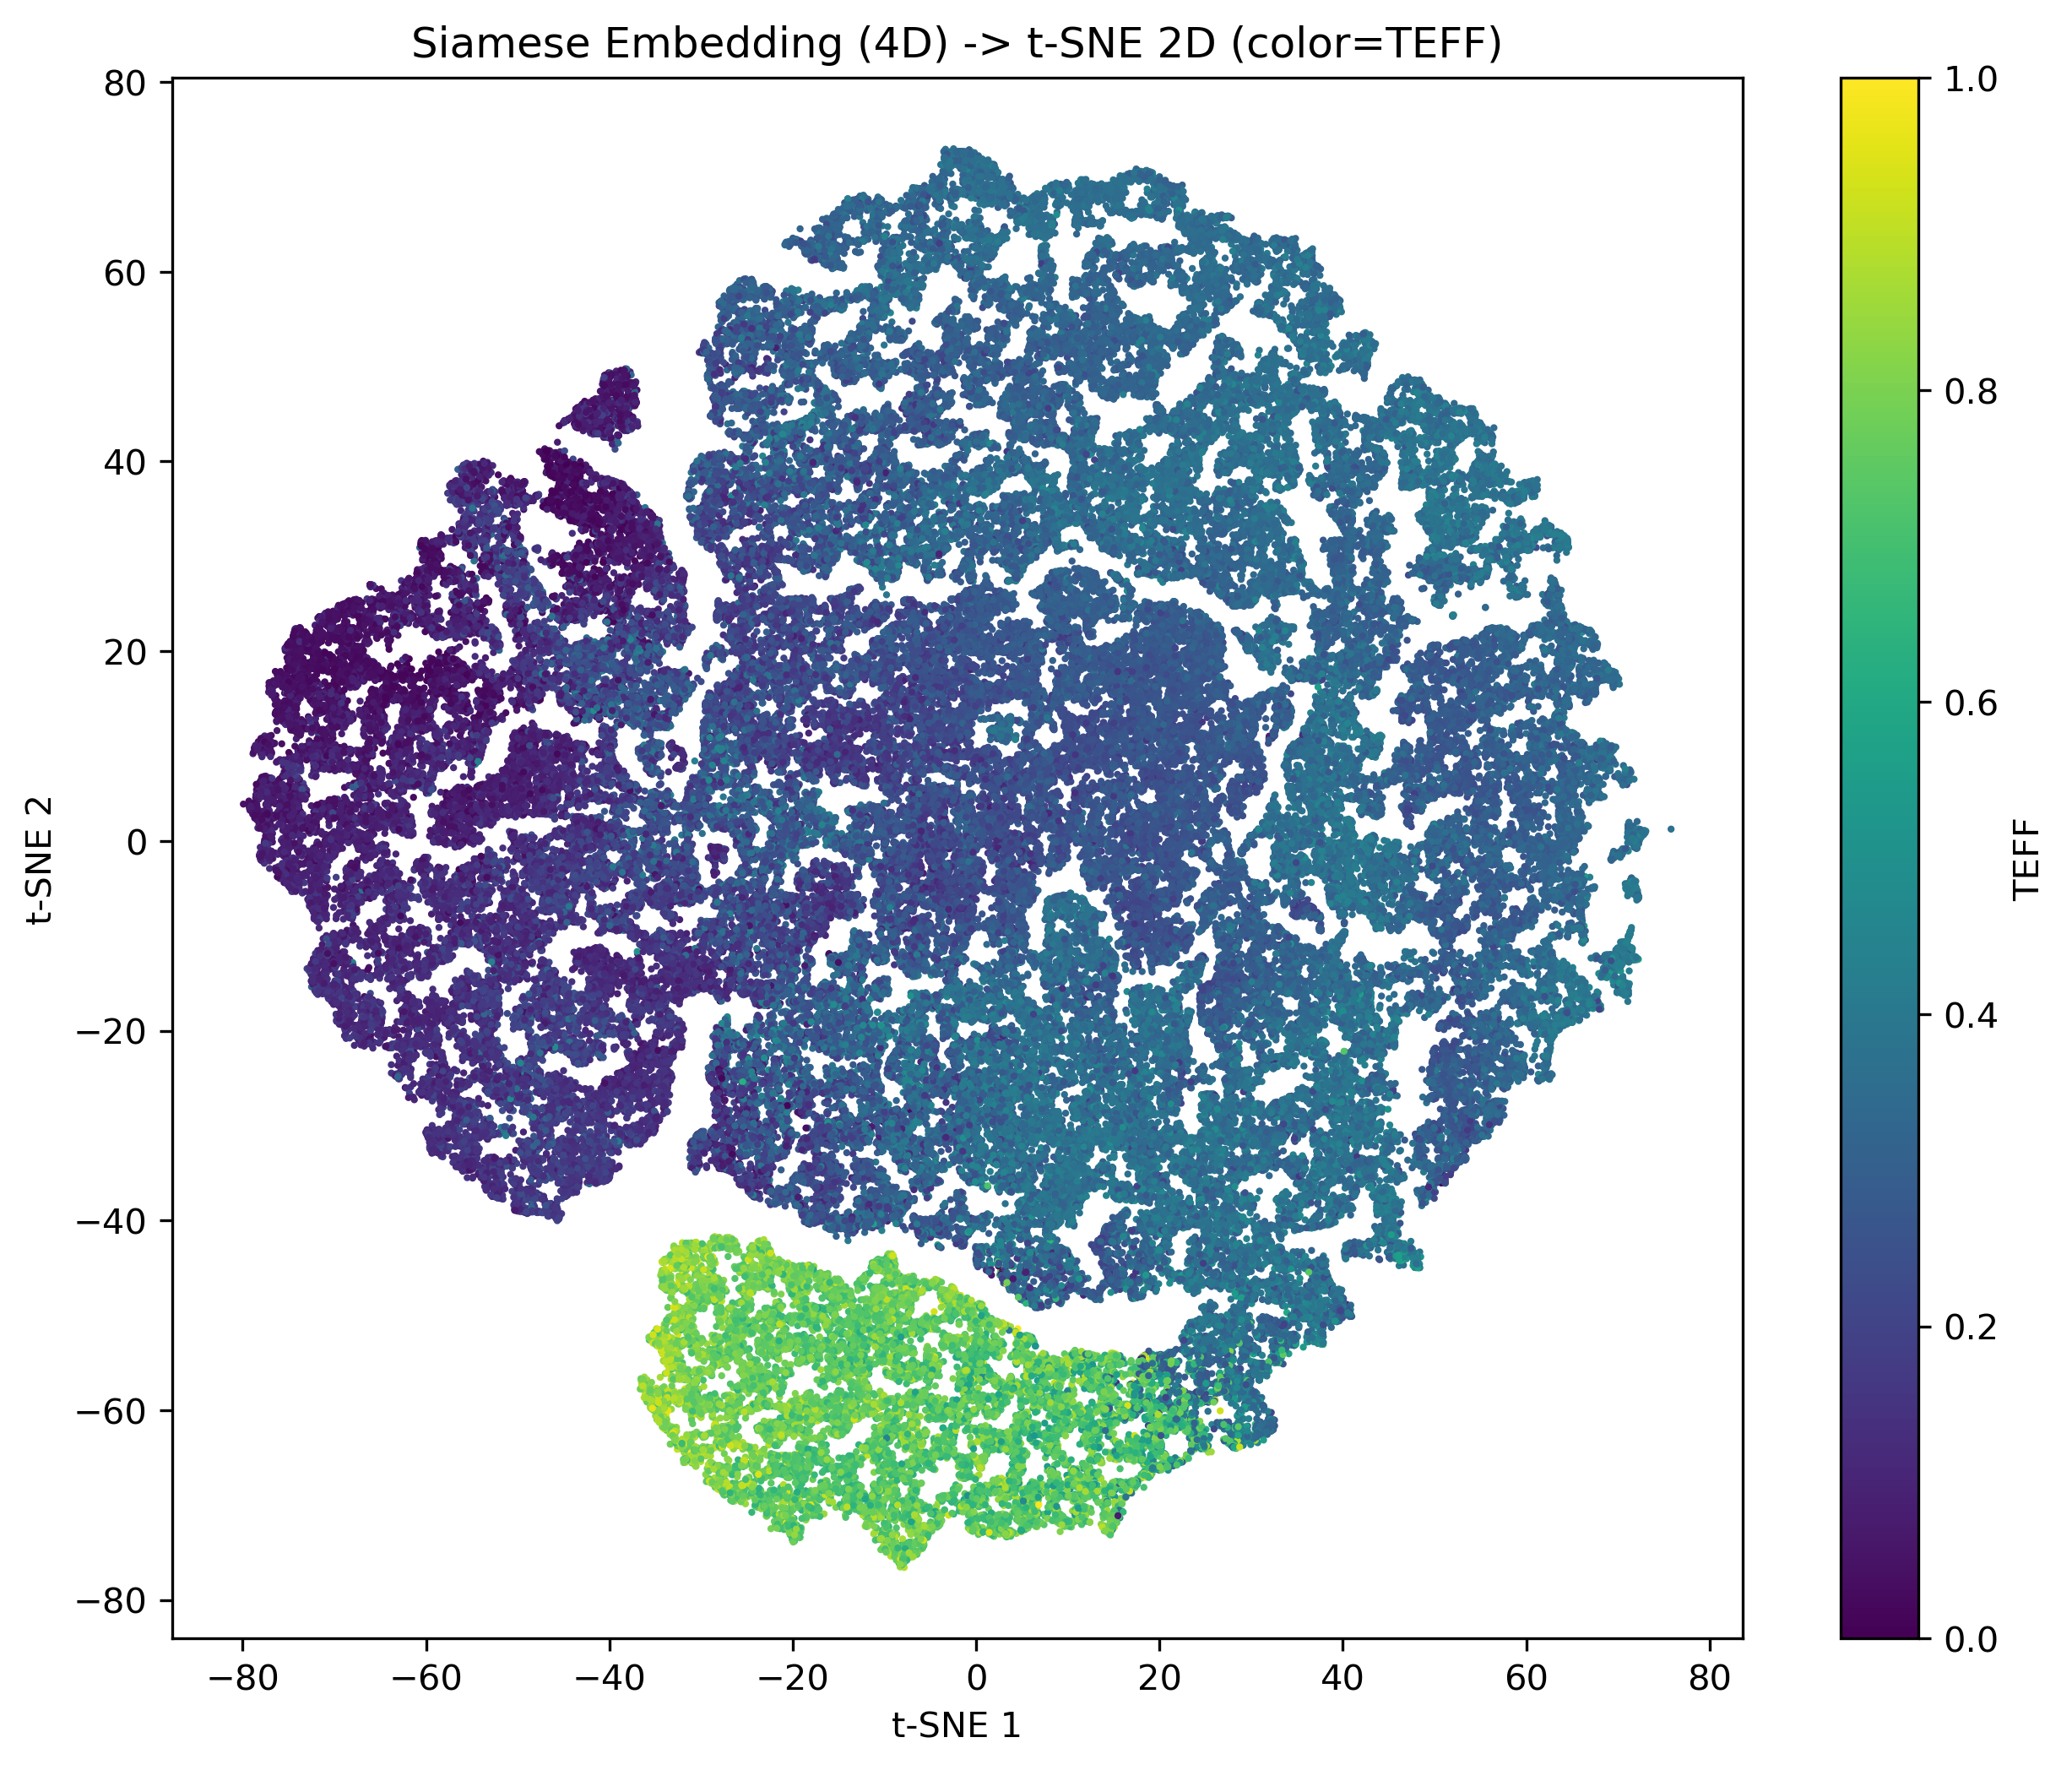

In [34]:
# Suppose we want the original TEFF from train+test concatenated
teff_all = torch.cat((y_teff_train, y_teff_test), dim=0).cpu().numpy()
logg_all = torch.cat((y_logg_train, y_logg_test), dim=0).cpu().numpy()
j_all = torch.cat((y_j_train, y_j_test), dim=0).cpu().numpy()
k_band = torch.cat((y_k_train, y_k_test), dim=0).cpu().numpy()
h_band = torch.cat((y_h_train, y_h_test), dim=0).cpu().numpy()

fig, ax = plt.subplots(figsize=(10,8), dpi=300)
sc = ax.scatter(z_2d_df["dim1"], z_2d_df["dim2"],
                c=teff_all, s=1.0, cmap='viridis')
plt.colorbar(sc, label="TEFF")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("Siamese Embedding (4D) -> t-SNE 2D (color=TEFF)")
plt.show()


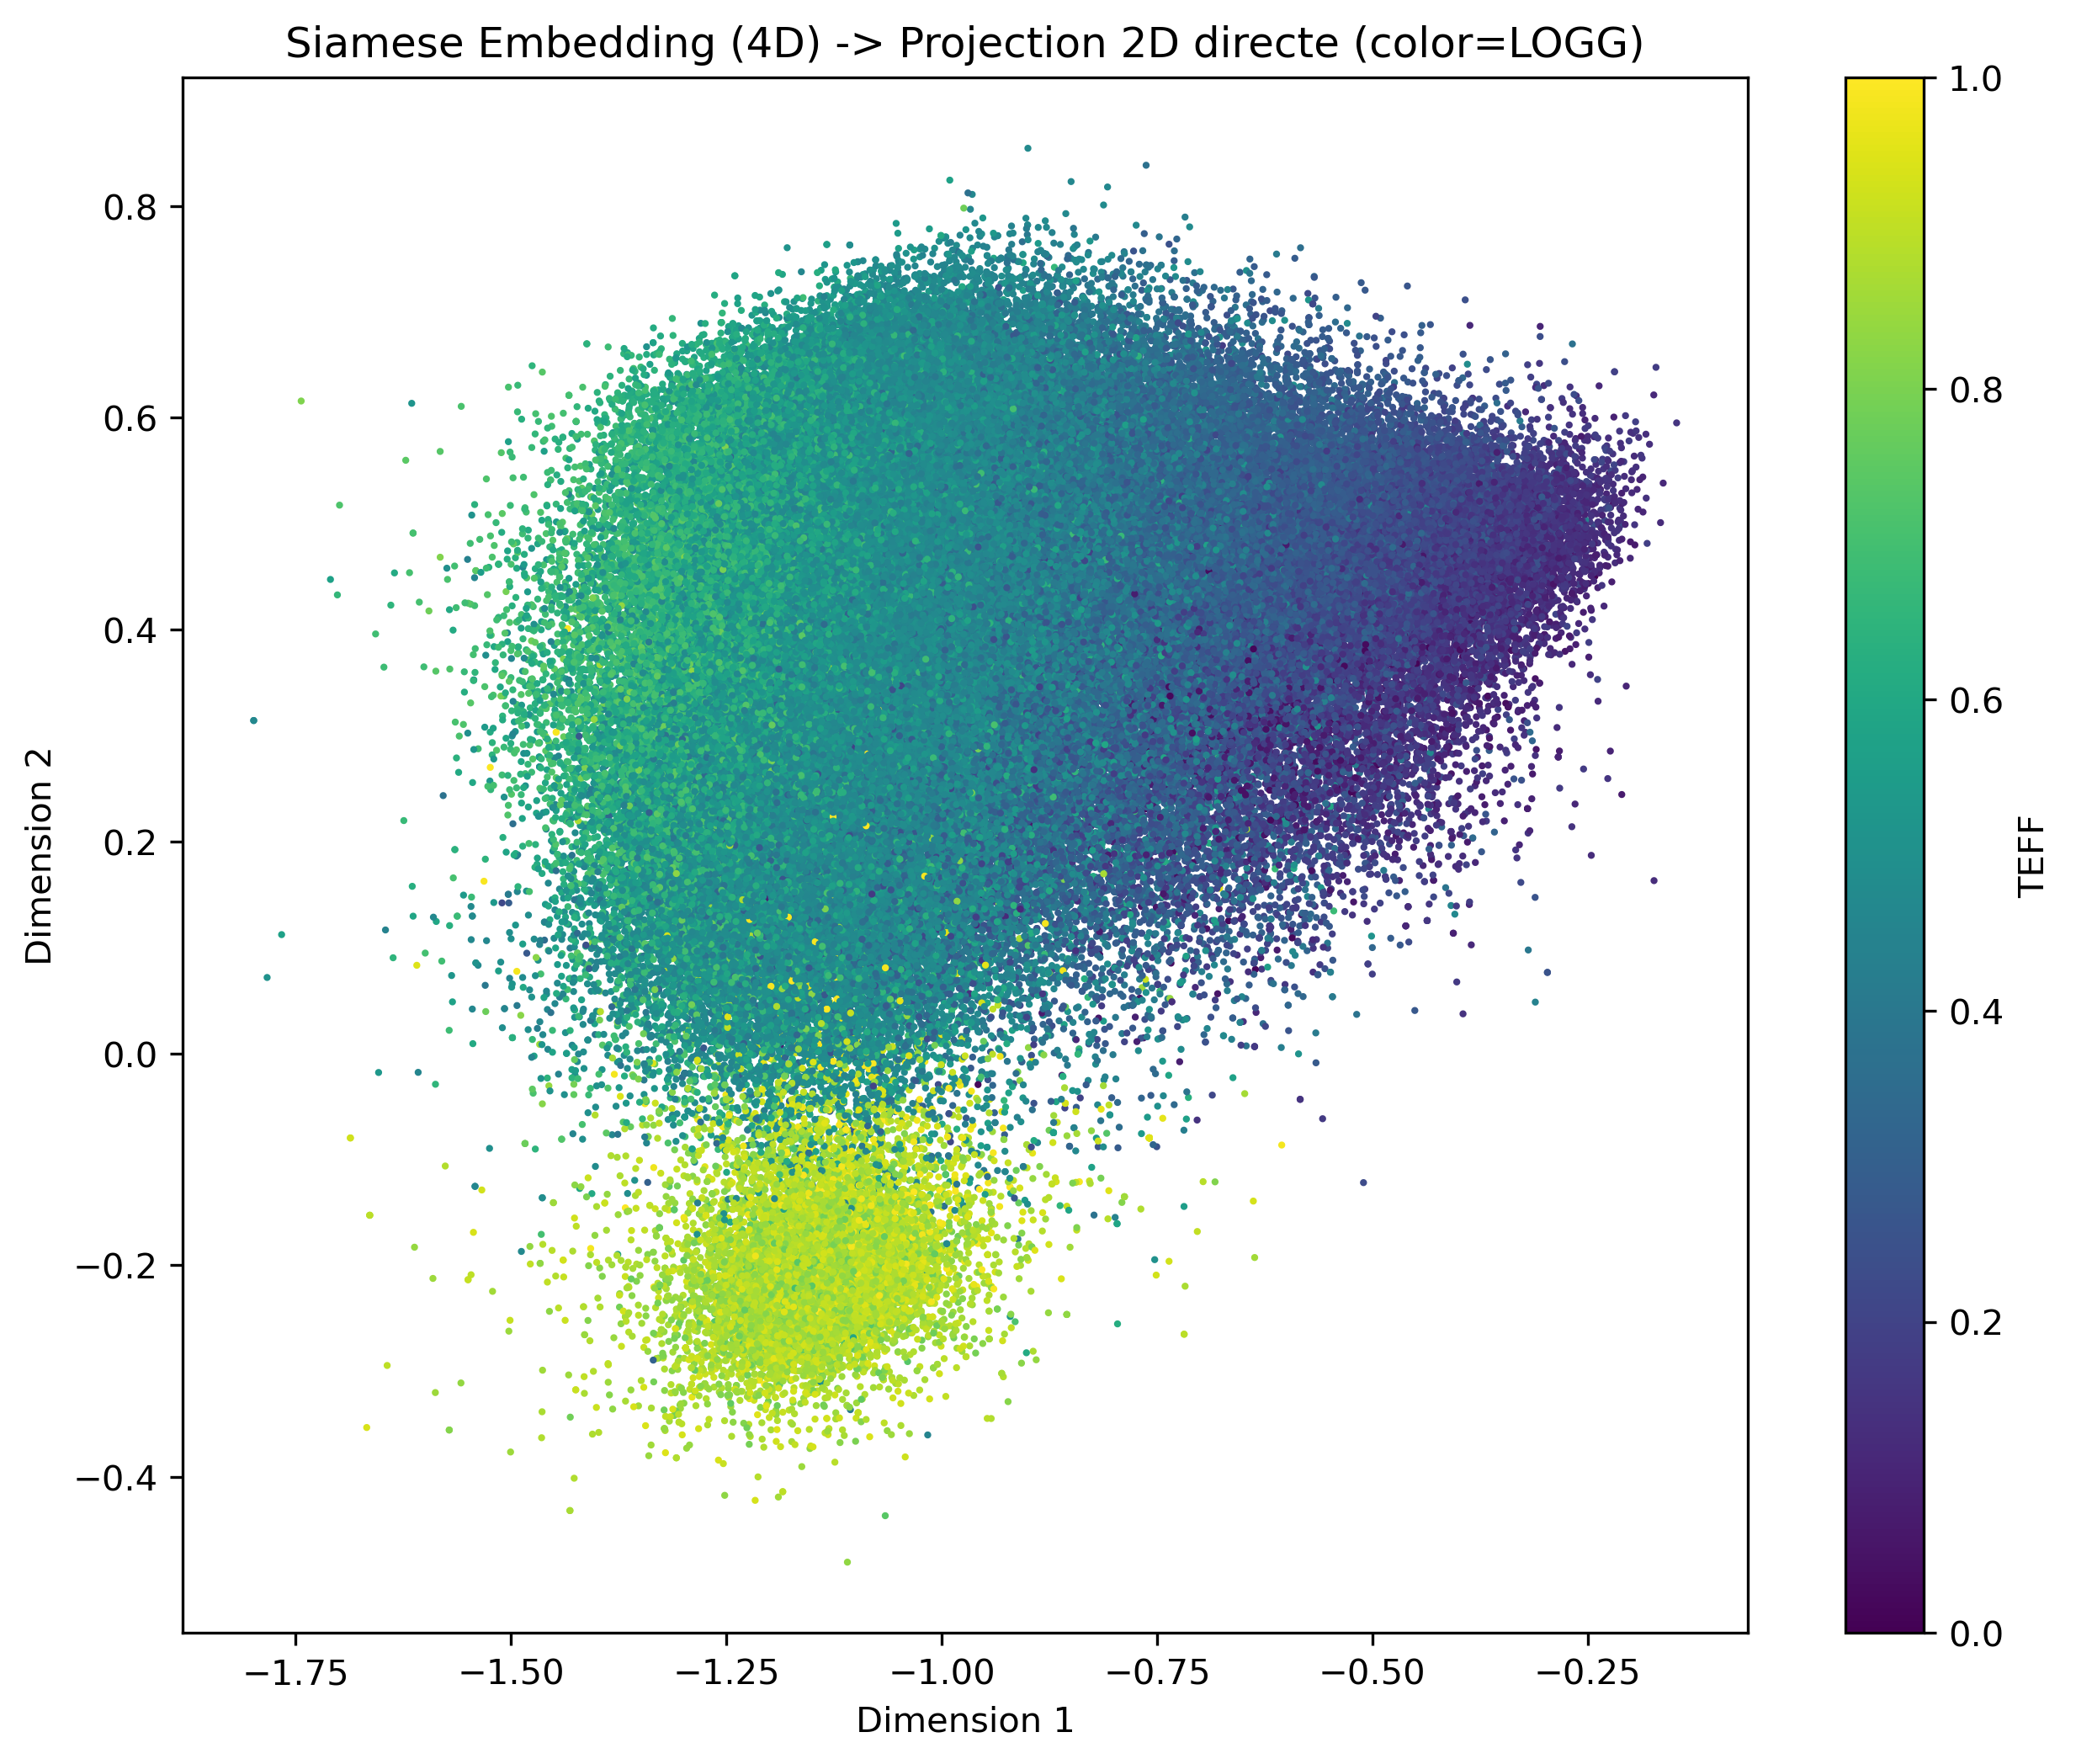

In [35]:
model.eval()
with torch.no_grad():
    # On concatène les données train et test et on les déplace sur le GPU
    X_all = torch.cat((X_train, X_test), dim=0).cuda()
    z_all, out_all = model.forward_once(X_all)  # z_all: [N, 4]

# Projection directe en 2D en sélectionnant les deux premières dimensions
z_2d_direct = z_all[:, :2].cpu().numpy()  # shape [N,2]

# Création d'un DataFrame pour faciliter le plotting (optionnel)
z_2d_df = pd.DataFrame(z_2d_direct, columns=["dim1", "dim2"])

# Concaténation des cibles TEFF (train+test)
teff_all = torch.cat((y_teff_train, y_teff_test), dim=0).cpu().numpy()
logg_all = torch.cat((y_logg_train, y_logg_test), dim=0).cpu().numpy()

# Plot
fig, ax = plt.subplots(figsize=(10,8), dpi=300)
sc = ax.scatter(z_2d_df["dim1"], z_2d_df["dim2"],
                c=logg_all, s=1.0, cmap='viridis')
plt.colorbar(sc, label="TEFF")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_title("Siamese Embedding (4D) -> Projection 2D directe (color=LOGG)")
plt.show()
